# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Rheza Priya Anargya 
- **Email:** rezhaanarga@gmail.com
- **ID Dicoding:** Rheza Priya Anargya 

## Menentukan Pertanyaan Bisnis

- Pertanyaan 1

Kategori produk apa yang menghasilkan revenue tertinggi pada tahun 2018, dan bagaimana trendnya per bulan?
- Pertanyaan 2

Kota mana yang memiliki repeat customer rate tertinggi selama periode 2016-2018 (dengan minimum 30 unique customers)?

## Import Semua Packages/Library yang Digunakan

In [18]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import os
from folium.plugins import HeatMap

## Data Wrangling

### Gathering Data

In [19]:
orders_df = pd.read_csv('data/E-Commerce Public Dataset/orders_dataset.csv')
order_items_df = pd.read_csv('data/E-Commerce Public Dataset/order_items_dataset.csv')
products_df = pd.read_csv('data/E-Commerce Public Dataset/products_dataset.csv')
customers_df = pd.read_csv('data/E-Commerce Public Dataset/customers_dataset.csv')
order_reviews_df = pd.read_csv('data/E-Commerce Public Dataset/order_reviews_dataset.csv')
product_category_translation_df = pd.read_csv('data/E-Commerce Public Dataset/product_category_name_translation.csv')

print("Data Shape:")
print("Orders:", orders_df.shape)
print("Order Items:", order_items_df.shape)
print("Products:", products_df.shape)
print("Customers:", customers_df.shape)
print("Order Reviews:", order_reviews_df.shape)
print("Product Category Translation:", product_category_translation_df.shape)

Data Shape:
Orders: (99441, 8)
Order Items: (112650, 7)
Products: (32951, 9)
Customers: (99441, 5)
Order Reviews: (99224, 7)
Product Category Translation: (71, 2)


**Insight:**
- Dataset mencakup 99,441 orders dari 99,441 customers, menunjukkan bahwa setiap order berasal dari satu customer
- Data review lengkap, memungkinkan analisis sentimen customer
- Terdapat 112,650 order items, lebih banyak dari jumlah orders, artinya rata-rata setiap order berisi lebih dari satu item produk (1.13 items per order)

### Assessing Data

In [20]:
# ===== ASSESSING ORDERS DATA =====
print("=" * 60)
print("ASSESSING ORDERS DATA")
print("=" * 60)

print("\n1. Data Info:")
print(orders_df.info())

print("\n2. First 5 Rows:")
print(orders_df.head())

print("\n3. Missing Values:")
print(orders_df.isnull().sum())

print("\n4. Data Statistics:")
print(orders_df.describe(include='all'))

# ===== CEK DUPLIKAT (WAJIB) =====
print("\n" + "=" * 60)
print("CEK DUPLIKAT DATA")
print("=" * 60)

duplicate_checks = {
    "orders_df": orders_df.duplicated().sum(),
    "order_items_df": order_items_df.duplicated().sum(),
    "products_df": products_df.duplicated().sum(),
    "customers_df": customers_df.duplicated().sum(),
    "order_reviews_df": order_reviews_df.duplicated().sum(),
    "product_category_translation_df": product_category_translation_df.duplicated().sum(),
}

for df_name, dup_count in duplicate_checks.items():
    print(f"{df_name}: {dup_count} baris duplikat")

# Optional cek duplikat berdasarkan key utama (lebih ketat)
print("\nCek duplikat berdasarkan key penting:")
print(f"order_id duplikat di orders_df: {orders_df['order_id'].duplicated().sum()}")
print(f"customer_id duplikat di customers_df: {customers_df['customer_id'].duplicated().sum()}")
print(f"product_id duplikat di products_df: {products_df['product_id'].duplicated().sum()}")

# ===== ASSESSING ORDER ITEMS DATA =====
print("\n" + "=" * 60)
print("ASSESSING ORDER ITEMS DATA")
print("=" * 60)

print("\n1. Data Info:")
print(order_items_df.info())

print("\n2. Missing Values:")
print(order_items_df.isnull().sum())

print("\n3. Price/Freight Statistics:")
print(order_items_df[['price', 'freight_value']].describe())

# ===== CEK OUTLIER (WAJIB) =====
print("\n" + "=" * 60)
print("CEK OUTLIER (IQR METHOD)")
print("=" * 60)

# revenue untuk kebutuhan assessing (sementara)
order_items_assess = order_items_df.copy()
order_items_assess['revenue'] = order_items_assess['price'] + order_items_assess['freight_value']

def iqr_outlier_summary(df, col):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_count = len(outliers)
    outlier_pct = (outlier_count / len(df)) * 100

    print(f"\nKolom: {col}")
    print(f"Q1: {q1:.2f} | Q3: {q3:.2f} | IQR: {iqr:.2f}")
    print(f"Lower bound: {lower:.2f} | Upper bound: {upper:.2f}")
    print(f"Jumlah outlier: {outlier_count:,} ({outlier_pct:.2f}%)")
    print(f"Nilai min: {df[col].min():.2f} | Nilai max: {df[col].max():.2f}")

for numeric_col in ['price', 'freight_value', 'revenue']:
    iqr_outlier_summary(order_items_assess, numeric_col)

# ===== ASSESSING PRODUCTS DATA =====
print("\n" + "=" * 60)
print("ASSESSING PRODUCTS DATA")
print("=" * 60)

print("\n1. Data Info:")
print(products_df.info())

print("\n2. Missing Values:")
print(products_df.isnull().sum())

print("\n3. Product Category:")
print(f"Total Unique Categories: {products_df['product_category_name'].nunique()}")

# ===== ASSESSING CUSTOMERS DATA =====
print("\n" + "=" * 60)
print("ASSESSING CUSTOMERS DATA")
print("=" * 60)

print("\n1. Data Info:")
print(customers_df.info())

print("\n2. Missing Values:")
print(customers_df.isnull().sum())

print("\n3. Sample data:")
print(customers_df.head())

# ===== CEK RELASI DATA =====
print("\n" + "=" * 60)
print("CEK RELASI DATA")
print("=" * 60)

# Cek apakah semua order_id di order_items ada di orders
missing_orders = set(order_items_df['order_id']) - set(orders_df['order_id'])
print(f"\nOrder items dengan order_id yang tidak ada di orders: {len(missing_orders)}")

# Cek apakah semua customer_id di orders ada di customers
missing_customers = set(orders_df['customer_id']) - set(customers_df['customer_id'])
print(f"Orders dengan customer_id yang tidak ada di customers: {len(missing_customers)}")

# Cek apakah semua product_id di order_items ada di products
missing_products = set(order_items_df['product_id']) - set(products_df['product_id'])
print(f"Order items dengan product_id yang tidak ada di products: {len(missing_products)}")

ASSESSING ORDERS DATA

1. Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB
None

2. First 5 Rows:
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20d

**Insight:**
- ORDERS: Terdapat missing values pada beberapa kolom timestamp:
  - `order_approved_at`: 160 missing
  - `order_delivered_carrier_date`: 1,783 missing
  - `order_delivered_customer_date`: 2,965 missing
  - Missing ini masih wajar karena sebagian order berstatus non-delivered (misalnya canceled/unavailable) atau belum mencapai tahap pengiriman/diterima customer.

- CEK DUPLIKAT: Tidak ditemukan baris duplikat pada seluruh dataframe utama (`orders_df`, `order_items_df`, `products_df`, `customers_df`, `order_reviews_df`, `product_category_translation_df`).
  - Duplikat pada key penting juga 0 (`order_id`, `customer_id`, `product_id`), sehingga data unik dan konsisten untuk analisis lanjutan.

- ORDER ITEMS: Data bersih dari missing values.
  - Price range: R$ 0.85 - R$ 6,735.00
  - Freight value range: R$ 0.00 - R$ 409.68
  - Terdapat outlier berdasarkan metode IQR:
    - `price`: 8,427 baris (7.48%)
    - `freight_value`: 12,134 baris (10.77%)
    - `revenue` (`price + freight_value`): 8,253 baris (7.33%)
  - Outlier kemungkinan merepresentasikan transaksi bernilai tinggi/premium dan ongkir tinggi, sehingga perlu dipertimbangkan saat interpretasi (tidak otomatis dihapus).

- PRODUCTS: Ditemukan missing values yang perlu ditangani pada tahap cleaning:
  - `product_category_name`, `product_name_lenght`, `product_description_lenght`, `product_photos_qty`: masing-masing 610 missing
  - `product_weight_g`, `product_length_cm`, `product_height_cm`, `product_width_cm`: masing-masing 2 missing
  - Total kategori produk unik: 73.

- CUSTOMERS: Data sangat clean, tidak ada missing values pada seluruh kolom utama customer.

- DATA INTEGRITY: Relasi antar tabel konsisten sepenuhnya.
  - Tidak ada `order_id` orphan di `order_items`
  - Tidak ada `customer_id` orphan di `orders`
  - Tidak ada `product_id` orphan di `order_items`
  - Data siap untuk proses cleaning dan merge lanjutan.

### Cleaning Data

In [21]:
# 1. Ubah timestamp ke datetime
print("=" * 60)
print("CONVERTING TIMESTAMP TO DATETIME")
print("=" * 60)

orders_df['order_purchase_timestamp'] = pd.to_datetime(orders_df['order_purchase_timestamp'])
orders_df['order_approved_at'] = pd.to_datetime(orders_df['order_approved_at'])
orders_df['order_delivered_carrier_date'] = pd.to_datetime(orders_df['order_delivered_carrier_date'])
orders_df['order_delivered_customer_date'] = pd.to_datetime(orders_df['order_delivered_customer_date'])
orders_df['order_estimated_delivery_date'] = pd.to_datetime(orders_df['order_estimated_delivery_date'])

print("Timestamp columns converted to datetime")

#  2. ekstrak informasi tanggal (year, month, date) untuk analisis tren
print("\n" + "=" * 60)
print("EXTRACTING DATE INFORMATION")
print("=" * 60)

orders_df['year'] = orders_df['order_purchase_timestamp'].dt.year
orders_df['month'] = orders_df['order_purchase_timestamp'].dt.month
orders_df['date'] = orders_df['order_purchase_timestamp'].dt.date
orders_df['year_month'] = orders_df['order_purchase_timestamp'].dt.to_period('M')

print("Year, month, date columns created")
print(f"\nDate range: {orders_df['order_purchase_timestamp'].min()} to {orders_df['order_purchase_timestamp'].max()}")
print(f"Years in dataset: {sorted(orders_df['year'].unique())}")

#  3. Handling missing product category
print("\n" + "=" * 60)
print("HANDLING MISSING PRODUCT CATEGORY")
print("=" * 60)

print(f"Missing product categories before: {products_df['product_category_name'].isnull().sum()}")

# isi missing category dengan 'uncategorized'
products_df['product_category_name'] = products_df['product_category_name'].fillna('uncategorized')

print(f"Missing product categories after: {products_df['product_category_name'].isnull().sum()}")
print("Missing categories replaced with 'uncategorized'")

#  4. merge semua tabel untuk analisis
print("\n" + "=" * 60)
print("MERGING TABLES")
print("=" * 60)

# Merge orders dengan order_items
merged_df = orders_df.merge(order_items_df, on='order_id', how='left')
print(f"After merge orders + order_items: {merged_df.shape}")

# Merge dengan products untuk category
merged_df = merged_df.merge(products_df[['product_id', 'product_category_name']], 
                            on='product_id', how='left')
print(f"After merge with products: {merged_df.shape}")

# Merge dengan product_category_translation untuk english names
merged_df = merged_df.merge(product_category_translation_df, 
                            on='product_category_name', 
                            how='left')
print(f"After merge with translation: {merged_df.shape}")

# Merge dengan customers untuk location
merged_df = merged_df.merge(customers_df[['customer_id', 'customer_city', 'customer_state']], 
                            on='customer_id', how='left')
print(f"After merge with customers: {merged_df.shape}")

print("All tables merged successfully")

#  5. membuat kolom revenue (price + freight_value)
print("\n" + "=" * 60)
print("CREATING REVENUE COLUMN")
print("=" * 60)

merged_df['revenue'] = merged_df['price'] + merged_df['freight_value']

print(f"Revenue column created")
print(f"Revenue statistics:")
print(merged_df['revenue'].describe())

#  6. filter untuk delivered orders
print("\n" + "=" * 60)
print("FILTERING DELIVERED ORDERS")
print("=" * 60)

print(f"Order status distribution BEFORE filtering:")
print(orders_df['order_status'].value_counts())

# Filter untuk delivered orders saja (untuk analisis pertanyaan 1)
delivered_orders = merged_df[merged_df['order_status'] == 'delivered'].copy()

print(f"\nTotal records after filtering delivered orders: {len(delivered_orders)}")

#  7. cek kualitas data (missing values, outliers) sebelum analisis
print("\n" + "=" * 60)
print("VERIFYING DATA QUALITY")
print("=" * 60)

print(f"\nMissing values in merged_df:")
print(merged_df.isnull().sum())

print(f"\nMissing values in delivered_orders:")
print(delivered_orders.isnull().sum())

print("\nData Cleaning Complete!")
print(f"\nDataset Summary:")
print(f"- Total merged records: {len(merged_df):,}")
print(f"- Delivered orders only: {len(delivered_orders):,}")
print(f"- Date range: {merged_df['year'].min()} - {merged_df['year'].max()}")
print(f"- Product categories: {merged_df['product_category_name_english'].nunique()}")
print(f"- Cities: {merged_df['customer_city'].nunique()}")

CONVERTING TIMESTAMP TO DATETIME
Timestamp columns converted to datetime

EXTRACTING DATE INFORMATION
Year, month, date columns created

Date range: 2016-09-04 21:15:19 to 2018-10-17 17:30:18
Years in dataset: [np.int32(2016), np.int32(2017), np.int32(2018)]

HANDLING MISSING PRODUCT CATEGORY
Missing product categories before: 610
Missing product categories after: 0
Missing categories replaced with 'uncategorized'

MERGING TABLES
After merge orders + order_items: (113425, 18)
After merge with products: (113425, 19)
After merge with translation: (113425, 20)
After merge with customers: (113425, 22)
All tables merged successfully

CREATING REVENUE COLUMN
Revenue column created
Revenue statistics:
count    112650.000000
mean        140.644059
std         190.724394
min           6.080000
25%          55.220000
50%          92.320000
75%         157.937500
max        6929.310000
Name: revenue, dtype: float64

FILTERING DELIVERED ORDERS
Order status distribution BEFORE filtering:
order_stat

**Insight:**
- Timestamp conversion berhasil, data date range: September 2016 - October 2018
  
- Ekstraksi date info: Sekarang ada kolom year, month, date untuk analisis tren
  
- Missing product category (610) berhasil di-handle dengan 'uncategorized'
  
- Merge berhasil mengkombinasikan semua 4 tabel utama menjadi 113,425 records dengan 20 columns
  
- Revenue column berhasil dibuat dengan statistik:
  - Min: R$ 6.08 | Mean: R$ 140.64 | Max: R$ 6,929.31
  - Outliers ada (ada produk dengan harga sangat tinggi)
  
- Filtering delivered orders: 96,478 orders delivered → 110,197 item-level records
  (completion rate 96.98%, sisanya canceled/unavailable/shipped)
  
- Data quality dalam delivered_orders: SANGAT CLEAN
  - Hanya 1,559 missing values di product_category_name_english
  - Semua kolom penting (price, revenue, city, category) lengkap
  
- Geographic coverage: 4,119 unique cities 

## Exploratory Data Analysis (EDA)

### Explore ...

In [22]:
# ===== EDA UNTUK PERTANYAAN 1 =====
print("=" * 70)
print("EDA: DISTRIBUSI KATEGORI PRODUK & REVENUE (TAHUN 2018)")
print("=" * 70)

# Filter data untuk tahun 2018
data_2018 = delivered_orders[delivered_orders['year'] == 2018].copy()

print(f"\nTotal records tahun 2018: {len(data_2018):,}")
print(f"Date range 2018: {data_2018['order_purchase_timestamp'].min()} to {data_2018['order_purchase_timestamp'].max()}")
print(f"Total revenue 2018: R$ {data_2018['revenue'].sum():,.2f}")

# 1. Distribusi revenue per kategori (tanpa kesimpulan)
print("\n" + "-" * 70)
print("1. DISTRIBUSI REVENUE PER KATEGORI PRODUK")
print("-" * 70)

revenue_by_category = data_2018.groupby('product_category_name_english').agg({
    'revenue': ['sum', 'mean', 'count'],
    'order_id': 'nunique'
}).round(2)

revenue_by_category.columns = ['total_revenue', 'avg_revenue_per_item', 'num_items', 'num_orders']
revenue_by_category = revenue_by_category.sort_values('total_revenue', ascending=False)

print("\nTop 15 kategori berdasarkan total revenue:")
print(revenue_by_category.head(15))

print("\nRingkasan statistik total_revenue per kategori:")
print(revenue_by_category['total_revenue'].describe().round(2))

# 2. Distribusi bulanan seluruh kategori (tanpa analisis trend top kategori)
print("\n" + "-" * 70)
print("2. DISTRIBUSI BULANAN (SEMUA KATEGORI, 2018)")
print("-" * 70)

monthly_all = data_2018.groupby('month').agg({
    'revenue': ['sum', 'mean', 'count'],
    'order_id': 'nunique'
}).round(2)

monthly_all.columns = ['total_revenue', 'avg_revenue_per_item', 'num_items', 'num_orders']
print("\nRingkasan bulanan:")
print(monthly_all)


# ===== EDA UNTUK PERTANYAAN 2 =====
print("\n\n" + "=" * 70)
print("EDA: DISTRIBUSI LOYALITAS CUSTOMER PER KOTA (2016-2018)")
print("=" * 70)

# Agregasi kota
city_customer_analysis = delivered_orders.groupby('customer_city').agg({
    'order_id': 'count',        # total order items
    'customer_id': 'nunique'    # unique customers
}).rename(columns={'order_id': 'total_orders', 'customer_id': 'unique_customers'})

# Repeat rate
city_customer_analysis['repeat_rate'] = (
    (city_customer_analysis['total_orders'] - city_customer_analysis['unique_customers'])
    / city_customer_analysis['unique_customers'] * 100
).round(2)

city_customer_analysis['avg_orders_per_customer'] = (
    city_customer_analysis['total_orders'] / city_customer_analysis['unique_customers']
).round(2)

# Sesuai pertanyaan bisnis: minimum 30 unique customers
city_customer_filtered = city_customer_analysis[city_customer_analysis['unique_customers'] >= 30].copy()
city_customer_filtered = city_customer_filtered.sort_values('repeat_rate', ascending=False)

print("\nTop 15 kota (repeat rate tertinggi, min 30 unique customers):")
print(city_customer_filtered.head(15))

print("\nRingkasan statistik repeat_rate (kota dengan min 30 unique customers):")
print(city_customer_filtered['repeat_rate'].describe().round(2))

# Distribusi revenue per kota (eksplorasi umum)
print("\n" + "-" * 70)
print("DISTRIBUSI REVENUE PER KOTA")
print("-" * 70)

revenue_by_city = delivered_orders.groupby('customer_city')['revenue'].agg(['sum', 'mean', 'count']).round(2)
revenue_by_city.columns = ['total_revenue', 'avg_revenue_per_item', 'num_items']
revenue_by_city = revenue_by_city.sort_values('total_revenue', ascending=False)

print("\nTop 10 kota berdasarkan total revenue:")
print(revenue_by_city.head(10))

EDA: DISTRIBUSI KATEGORI PRODUK & REVENUE (TAHUN 2018)

Total records tahun 2018: 60,324
Date range 2018: 2018-01-01 02:48:41 to 2018-08-29 15:00:37
Total revenue 2018: R$ 8,451,584.77

----------------------------------------------------------------------
1. DISTRIBUSI REVENUE PER KATEGORI PRODUK
----------------------------------------------------------------------

Top 15 kategori berdasarkan total revenue:
                               total_revenue  avg_revenue_per_item  num_items  \
product_category_name_english                                                   
health_beauty                      866810.34                148.40       5841   
watches_gifts                      749738.44                206.65       3628   
bed_bath_table                     643653.48                110.78       5810   
sports_leisure                     604393.87                136.25       4436   
computers_accessories              583989.37                126.35       4622   
housewares         

**Insight:**

**Pertanyaan 1 - Distribusi Kategori Produk dan Revenue (2018)**
- Data tahun 2018 mencakup 60,324 item-level records dengan total revenue R$ 8,451,584.77 pada periode Januari-Agustus 2018.
- Distribusi revenue per kategori menunjukkan konsentrasi pada beberapa kategori teratas, yaitu health_beauty (R$ 866,810.34), watches_gifts (R$ 749,738.44), dan bed_bath_table (R$ 643,653.48).
- Ringkasan statistik total revenue per kategori memperlihatkan median R$ 33,849.83 dan mean R$ 119,490.27.
- Distribusi bulanan menunjukkan total revenue berada pada rentang sekitar R$ 966 ribu sampai R$ 1,133 juta per bulan, dengan volume item bulanan sekitar 6,963 sampai 8,037 item.

**Pertanyaan 2 - Distribusi Loyalitas Customer per Kota (2016-2018)**
- Dengan filter minimum 30 unique customers per kota, terdapat 400 kota yang masuk ke analisis.
- Ringkasan repeat rate kota menunjukkan mean 14.15%, median 13.68%, dengan rentang 0.00% hingga 46.51%.
- Kota dengan nilai repeat rate tertinggi pada hasil agregasi ini adalah peruibe (46.51%), rio verde (42.19%), dan itupeva (40.48%).
- Pada kota-kota dengan repeat rate tinggi, nilai avg_orders_per_customer berada di kisaran 1.27 sampai 1.47.
- Distribusi revenue per kota menunjukkan nilai tertinggi berada pada kota besar seperti sao paulo (R$ 2,107,960.17), rio de janeiro (R$ 1,111,732.21), dan belo horizonte (R$ 405,950.51).

## Visualization & Explanatory Analysis

### Pertanyaan 1:

VISUALIZATION: PERTANYAAN 1 - KATEGORI REVENUE TERTINGGI & TREND BULANAN (2018)

Kategori dengan revenue tertinggi 2018: health_beauty
Total revenue kategori tersebut: R$ 866,810.34
Kontribusi terhadap total revenue 2018: 10.26%

Ringkasan trend bulanan kategori teratas:
   month    revenue  share_pct
0      1   81989.68       7.61
1      2   95463.05       9.88
2      3   97035.83       8.66
3      4  104332.90       9.21
4      5  108261.36       9.59
5      6  123857.97      12.24
6      7  120225.04      11.70
7      8  135644.51      13.76

Peak revenue: Bulan 8 (R$ 135,644.51)
Terendah: Bulan 1 (R$ 81,989.68)
Growth bulan awal ke bulan akhir: +65.44%


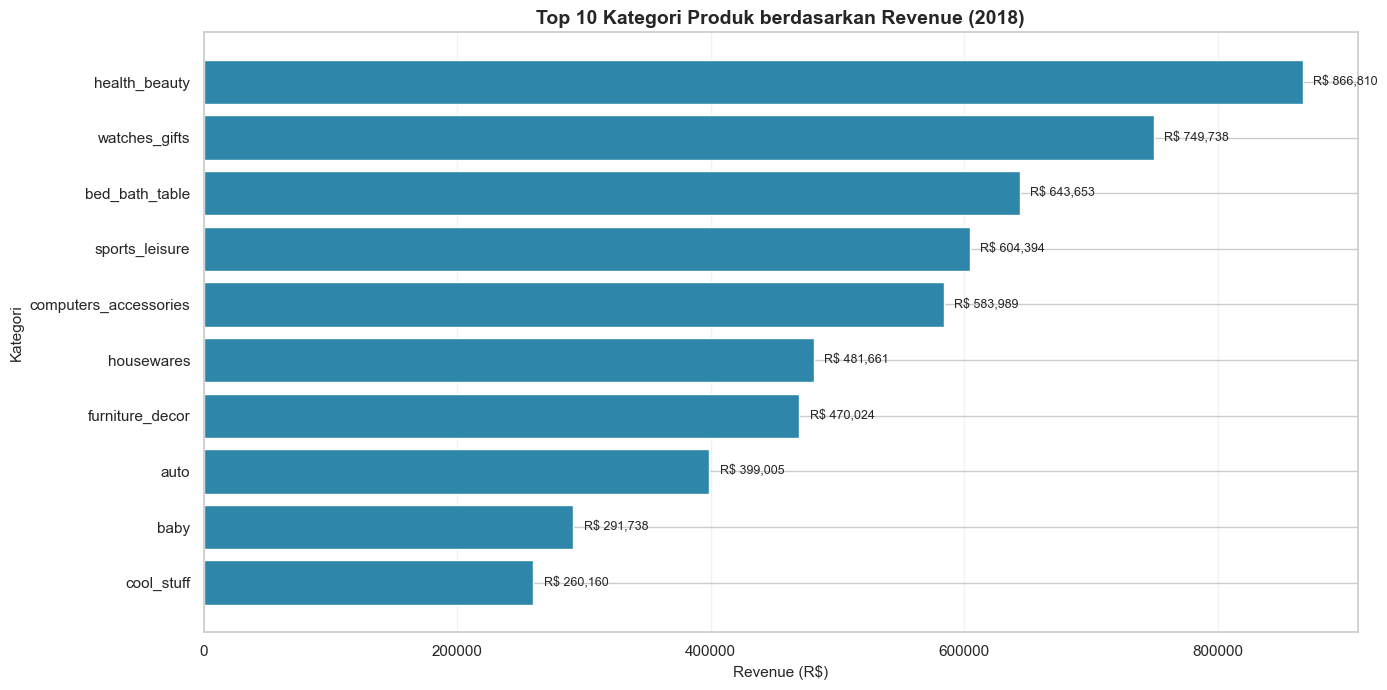

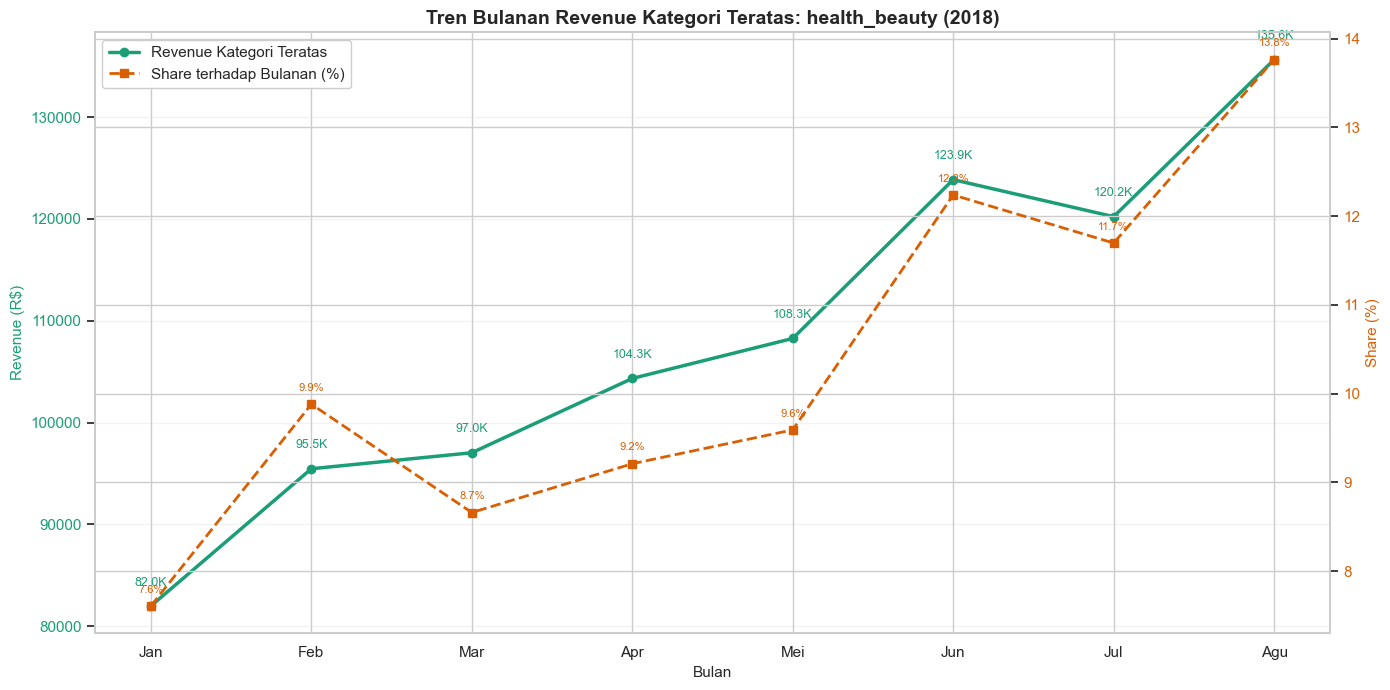

In [23]:
# ===== VISUALIZATION & EXPLANATORY ANALYSIS - PERTANYAAN 1 =====
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["font.size"] = 10

print("=" * 70)
print("VISUALIZATION: PERTANYAAN 1 - KATEGORI REVENUE TERTINGGI & TREND BULANAN (2018)")
print("=" * 70)

# 1) Siapkan data 2018
data_2018 = delivered_orders[delivered_orders["year"] == 2018].copy()

# Agregasi revenue kategori
revenue_by_category = (
    data_2018.groupby("product_category_name_english", as_index=False)["revenue"]
    .sum()
    .sort_values("revenue", ascending=False)
)

total_revenue_2018 = data_2018["revenue"].sum()
top_category = revenue_by_category.iloc[0]["product_category_name_english"]
top_category_revenue = revenue_by_category.iloc[0]["revenue"]
top_category_share = (top_category_revenue / total_revenue_2018) * 100

print(f"\nKategori dengan revenue tertinggi 2018: {top_category}")
print(f"Total revenue kategori tersebut: R$ {top_category_revenue:,.2f}")
print(f"Kontribusi terhadap total revenue 2018: {top_category_share:.2f}%")

# 2) Tren bulanan untuk kategori teratas
monthly_top_category = (
    data_2018[data_2018["product_category_name_english"] == top_category]
    .groupby("month", as_index=False)["revenue"]
    .sum()
    .sort_values("month")
)

monthly_all = (
    data_2018.groupby("month", as_index=False)["revenue"]
    .sum()
    .sort_values("month")
    .rename(columns={"revenue": "total_month_revenue"})
)

monthly_top_category = monthly_top_category.merge(monthly_all, on="month", how="left")
monthly_top_category["share_pct"] = (
    monthly_top_category["revenue"] / monthly_top_category["total_month_revenue"] * 100
)

# Statistik trend
peak_row = monthly_top_category.loc[monthly_top_category["revenue"].idxmax()]
low_row = monthly_top_category.loc[monthly_top_category["revenue"].idxmin()]
first_month_rev = monthly_top_category.iloc[0]["revenue"]
last_month_rev = monthly_top_category.iloc[-1]["revenue"]
growth_pct = ((last_month_rev - first_month_rev) / first_month_rev * 100) if first_month_rev != 0 else 0

print("\nRingkasan trend bulanan kategori teratas:")
print(monthly_top_category[["month", "revenue", "share_pct"]].round(2))
print(f"\nPeak revenue: Bulan {int(peak_row['month'])} (R$ {peak_row['revenue']:,.2f})")
print(f"Terendah: Bulan {int(low_row['month'])} (R$ {low_row['revenue']:,.2f})")
print(f"Growth bulan awal ke bulan akhir: {growth_pct:+.2f}%")

# =========================
# CHART 1: Top 10 kategori revenue
# =========================
fig, ax = plt.subplots(figsize=(14, 7))

top10 = revenue_by_category.head(10).copy()
top10 = top10.sort_values("revenue", ascending=True)  # agar bar horizontal rapi

bars = ax.barh(top10["product_category_name_english"], top10["revenue"], color="#2E86AB")

for i, val in enumerate(top10["revenue"].values):
    ax.text(val + 8000, i, f"R$ {val:,.0f}", va="center", fontsize=9)

ax.set_title("Top 10 Kategori Produk berdasarkan Revenue (2018)", fontsize=14, fontweight="bold")
ax.set_xlabel("Revenue (R$)", fontsize=11)
ax.set_ylabel("Kategori", fontsize=11)
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

# =========================
# CHART 2: Tren bulanan kategori teratas
# =========================
fig, ax1 = plt.subplots(figsize=(14, 7))

months = monthly_top_category["month"].astype(int).values
month_labels = ["Jan", "Feb", "Mar", "Apr", "Mei", "Jun", "Jul", "Agu", "Sep", "Okt", "Nov", "Des"]
labels = [month_labels[m - 1] for m in months]

# Line revenue kategori teratas
ax1.plot(months, monthly_top_category["revenue"], color="#1B9E77", marker="o", linewidth=2.5, label="Revenue Kategori Teratas")
ax1.set_xlabel("Bulan", fontsize=11)
ax1.set_ylabel("Revenue (R$)", fontsize=11, color="#1B9E77")
ax1.tick_params(axis="y", labelcolor="#1B9E77")
ax1.set_xticks(months)
ax1.set_xticklabels(labels)
ax1.grid(axis="y", alpha=0.25)

# Label titik revenue
for x, y in zip(months, monthly_top_category["revenue"]):
    ax1.text(x, y + 2000, f"{y/1000:.1f}K", ha="center", fontsize=9, color="#1B9E77")

# Secondary axis: share terhadap total revenue bulanan
ax2 = ax1.twinx()
ax2.plot(months, monthly_top_category["share_pct"], color="#D95F02", marker="s", linewidth=2.0, linestyle="--", label="Share terhadap Bulanan (%)")
ax2.set_ylabel("Share (%)", fontsize=11, color="#D95F02")
ax2.tick_params(axis="y", labelcolor="#D95F02")

for x, y in zip(months, monthly_top_category["share_pct"]):
    ax2.text(x, y + 0.15, f"{y:.1f}%", ha="center", fontsize=8, color="#D95F02")

# Gabung legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", framealpha=0.95)

ax1.set_title(
    f"Tren Bulanan Revenue Kategori Teratas: {top_category} (2018)",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

### Pertanyaan 2:


VISUALIZATION: PERTANYAAN 2 - REPEAT CUSTOMER RATE PER KOTA (2016-2018)

Total kota yang memenuhi syarat (min 30 unique customers): 389

Top 15 kota dengan repeat customer rate tertinggi:
              customer_city  repeat_rate  repeat_customers  unique_customers  \
3615              saquarema        13.16                 5                38   
1299                extrema        10.53                 4                38   
2118               luziania        10.00                 3                30   
3881                tubarao         9.09                 5                55   
1847              ituiutaba         9.09                 4                44   
1966         joao monlevade         8.70                 4                46   
3177           rondonopolis         8.47                 5                59   
2954           porto seguro         8.33                 3                36   
382               barbacena         8.22                 6                73   
1257       

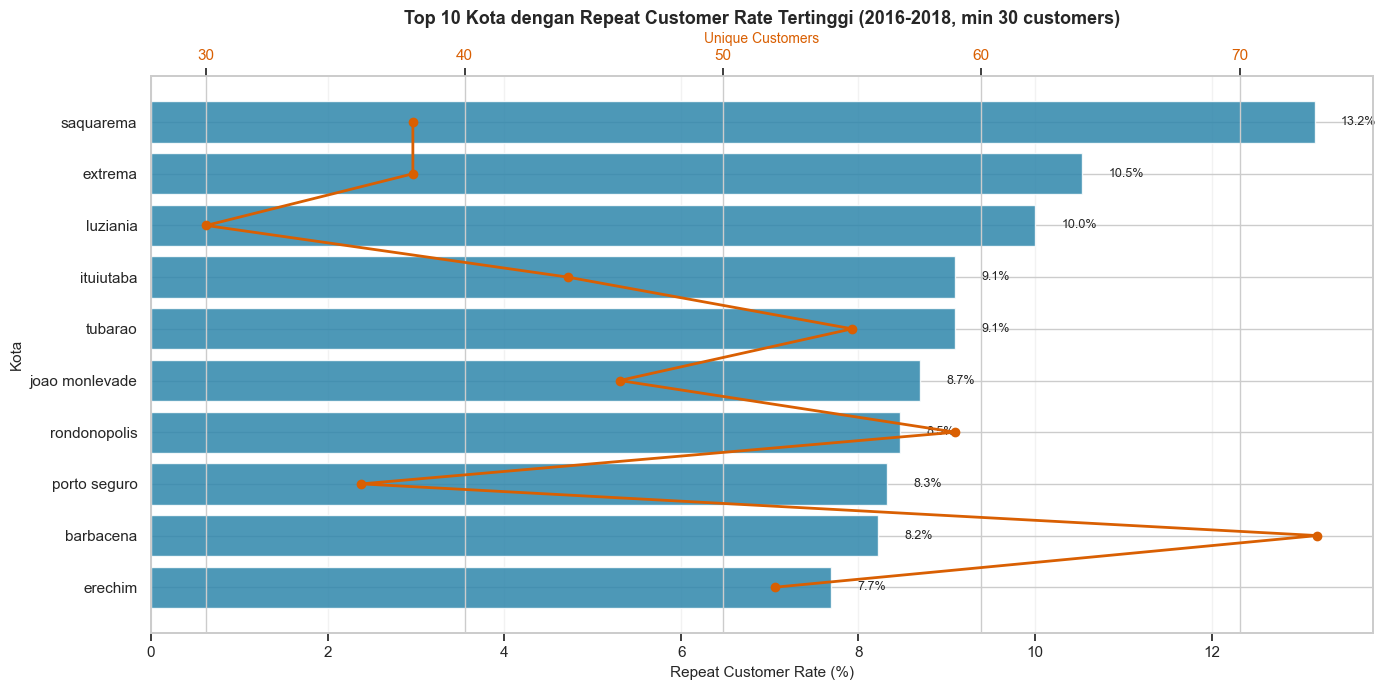


Repeat customer rate tahunan untuk top 3 kota:
   year customer_city  unique_customers  repeat_customers  repeat_rate
0  2017       extrema                16                 3        18.75
3  2018       extrema                22                 1         4.55
1  2017      luziania                15                 1         6.67
4  2018      luziania                16                 1         6.25
2  2017     saquarema                17                 3        17.65
5  2018     saquarema                21                 2         9.52


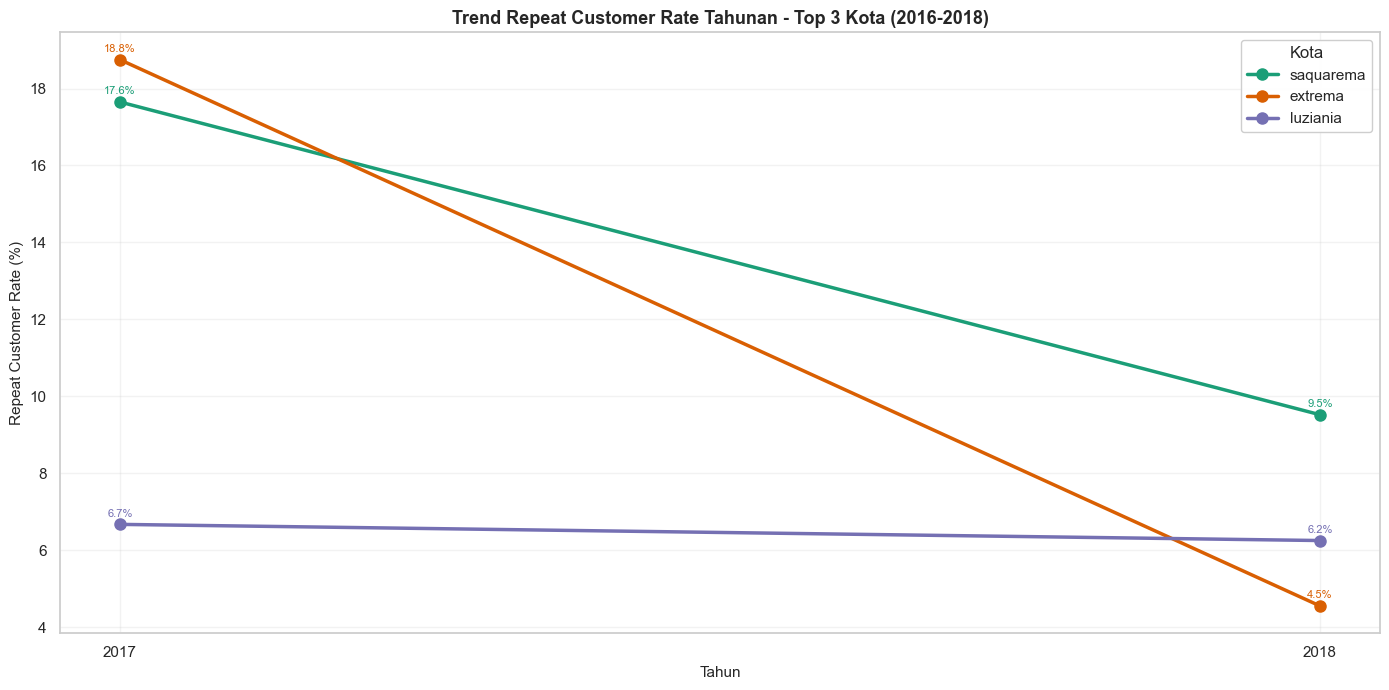

In [24]:
# ===== VISUALIZATION & EXPLANATORY ANALYSIS - PERTANYAAN 2 =====
print("\n" + "=" * 70)
print("VISUALIZATION: PERTANYAAN 2 - REPEAT CUSTOMER RATE PER KOTA (2016-2018)")
print("=" * 70)

# Pastikan customer_unique_id tersedia
if "customer_unique_id" not in delivered_orders.columns:
    delivered_orders = delivered_orders.merge(
        customers_df[["customer_id", "customer_unique_id"]],
        on="customer_id",
        how="left"
    )

# Gunakan level order (bukan item) agar repeat rate tidak bias karena multi-item
orders_city = delivered_orders[
    ["order_id", "customer_unique_id", "customer_city", "year"]
].drop_duplicates()

# Batasi periode 2016-2018 sesuai pertanyaan bisnis
orders_city = orders_city[orders_city["year"].between(2016, 2018)].copy()

# Hitung jumlah order per customer per city
cust_city_orders = (
    orders_city.groupby(["customer_city", "customer_unique_id"])["order_id"]
    .nunique()
    .reset_index(name="orders_per_customer")
)

# Summary per city
city_summary = cust_city_orders.groupby("customer_city").agg(
    unique_customers=("customer_unique_id", "nunique"),
    repeat_customers=("orders_per_customer", lambda x: (x >= 2).sum()),
    avg_orders_per_customer=("orders_per_customer", "mean")
).reset_index()

city_total_orders = (
    orders_city.groupby("customer_city")["order_id"]
    .nunique()
    .reset_index(name="total_orders")
)

city_summary = city_summary.merge(city_total_orders, on="customer_city", how="left")
city_summary["repeat_rate"] = (
    city_summary["repeat_customers"] / city_summary["unique_customers"] * 100
).round(2)

# Filter minimum 30 unique customers
city_filtered = city_summary[city_summary["unique_customers"] >= 30].copy()
city_filtered = city_filtered.sort_values("repeat_rate", ascending=False)

print(f"\nTotal kota yang memenuhi syarat (min 30 unique customers): {len(city_filtered)}")
print("\nTop 15 kota dengan repeat customer rate tertinggi:")
print(
    city_filtered[
        ["customer_city", "repeat_rate", "repeat_customers", "unique_customers", "avg_orders_per_customer", "total_orders"]
    ].head(15)
)

best_row = city_filtered.iloc[0]
print("\nKota dengan repeat customer rate tertinggi:")
print(
    f"- {best_row['customer_city']} | repeat_rate: {best_row['repeat_rate']:.2f}% "
    f"| repeat_customers: {int(best_row['repeat_customers'])} "
    f"| unique_customers: {int(best_row['unique_customers'])}"
)

# =========================
# CHART 1: Top 10 Repeat Rate (dengan ukuran basis customer)
# =========================
top10_repeat = city_filtered.head(10).sort_values("repeat_rate", ascending=True)

fig, ax1 = plt.subplots(figsize=(14, 7))
ax1.barh(top10_repeat["customer_city"], top10_repeat["repeat_rate"], color="#2E86AB", alpha=0.85)
ax1.set_xlabel("Repeat Customer Rate (%)", fontsize=11)
ax1.set_ylabel("Kota", fontsize=11)
ax1.set_title("Top 10 Kota dengan Repeat Customer Rate Tertinggi (2016-2018, min 30 customers)",
              fontsize=13, fontweight="bold")
ax1.grid(axis="x", alpha=0.25)

for i, v in enumerate(top10_repeat["repeat_rate"].values):
    ax1.text(v + 0.3, i, f"{v:.1f}%", va="center", fontsize=9)

# axis kedua: unique customer agar konteks sample size jelas
ax2 = ax1.twiny()
ax2.plot(top10_repeat["unique_customers"].values, range(len(top10_repeat)),
         color="#D95F02", marker="o", linewidth=2, label="Unique Customers")
ax2.set_xlabel("Unique Customers", color="#D95F02", fontsize=10)
ax2.tick_params(axis="x", labelcolor="#D95F02")

plt.tight_layout()
plt.show()

# =========================
# CHART 2: Trend Repeat Rate Tahunan untuk Top 3 Kota
# =========================
top3_cities = city_filtered.head(3)["customer_city"].tolist()

cust_year_city_orders = (
    orders_city[orders_city["customer_city"].isin(top3_cities)]
    .groupby(["year", "customer_city", "customer_unique_id"])["order_id"]
    .nunique()
    .reset_index(name="orders_per_customer")
)

yearly_repeat = cust_year_city_orders.groupby(["year", "customer_city"]).agg(
    unique_customers=("customer_unique_id", "nunique"),
    repeat_customers=("orders_per_customer", lambda x: (x >= 2).sum())
).reset_index()

yearly_repeat["repeat_rate"] = (
    yearly_repeat["repeat_customers"] / yearly_repeat["unique_customers"] * 100
).round(2)

print("\nRepeat customer rate tahunan untuk top 3 kota:")
print(yearly_repeat.sort_values(["customer_city", "year"]))

fig, ax = plt.subplots(figsize=(14, 7))
colors = ["#1B9E77", "#D95F02", "#7570B3"]

for i, city in enumerate(top3_cities):
    city_data = yearly_repeat[yearly_repeat["customer_city"] == city].sort_values("year")
    ax.plot(city_data["year"], city_data["repeat_rate"],
            marker="o", linewidth=2.5, markersize=8, color=colors[i], label=city)

    for x, y in zip(city_data["year"], city_data["repeat_rate"]):
        ax.text(x, y + 0.2, f"{y:.1f}%", ha="center", fontsize=8, color=colors[i])

ax.set_xlabel("Tahun", fontsize=11)
ax.set_ylabel("Repeat Customer Rate (%)", fontsize=11)
ax.set_title("Trend Repeat Customer Rate Tahunan - Top 3 Kota (2016-2018)",
             fontsize=13, fontweight="bold")
ax.grid(True, alpha=0.25)
ax.set_xticks(sorted(yearly_repeat["year"].unique()))
ax.legend(title="Kota", framealpha=0.95)

plt.tight_layout()
plt.show()

**Insight:**

**Pertanyaan 1**

- Pada tahun 2018, kategori dengan revenue tertinggi adalah **health_beauty** dengan total revenue **R$ 866,810.34**.
- Kategori ini berkontribusi sebesar **10.26%** terhadap total revenue 2018, sehingga menjadi kontributor terbesar secara kategori.
- Tren bulanan health_beauty menunjukkan pola **meningkat secara umum** dari awal hingga akhir periode pengamatan (Januari-Agustus), meskipun terdapat fluktuasi kecil di pertengahan tahun.
- Revenue terendah terjadi pada **bulan 1** sebesar **R$ 81,989.68**, sedangkan revenue tertinggi terjadi pada **bulan 8** sebesar **R$ 135,644.51**.
- Dari bulan awal ke bulan akhir periode, revenue kategori ini tumbuh **+65.44%**, yang mengindikasikan penguatan performa sepanjang tahun.
- Porsi kontribusi bulanan (share) health_beauty naik dari **7.61%** di bulan 1 menjadi **13.76%** di bulan 8, menunjukkan bahwa pertumbuhan kategori ini bukan hanya nominal, tetapi juga semakin dominan terhadap total revenue bulanan.
- Secara bisnis, health_beauty dapat diposisikan sebagai kategori prioritas untuk strategi pertumbuhan, sambil tetap memantau kestabilan performa bulanannya.


**Pertanyaan 2**

- Setelah menerapkan filter minimum 30 unique customers, terdapat **389 kota** yang memenuhi kriteria analisis.
- Kota dengan repeat customer rate tertinggi adalah **saquarema** dengan nilai **13.16%** (5 repeat customers dari 38 unique customers).
- Posisi berikutnya ditempati oleh **extrema (10.53%)** dan **luziania (10.00%)**.
- Pada daftar 15 kota teratas, nilai **avg_orders_per_customer** berada di kisaran **1.07-1.20**. Ini menunjukkan pembelian ulang sudah ada, tetapi mayoritas pelanggan masih melakukan transaksi satu kali.

- Tren tahunan untuk top 3 kota menunjukkan:
  - **saquarema:** turun dari **17.65% (2017)** menjadi **9.52% (2018)**
  - **extrema:** turun tajam dari **18.75% (2017)** menjadi **4.55% (2018)**
  - **luziania:** relatif stabil dari **6.67% (2017)** menjadi **6.25% (2018)**

- Kesimpulannya, repeat customer rate tertinggi memang ada pada kota-kota tertentu, tetapi basis repeat customer secara absolut masih kecil. Fokus bisnis sebaiknya diarahkan pada strategi retensi untuk mendorong pelanggan first purchase menjadi pembeli kedua, terutama di kota dengan basis customer yang sudah cukup besar.

## Analisis Lanjutan (Opsional)

1. RFM ANALYSIS

Ringkasan RFM:
        Recency  Frequency  Monetary
count  93358.00   93358.00  93358.00
mean     237.94       1.03    165.17
std      152.59       0.21    226.29
min        1.00       1.00      9.59
25%      114.00       1.00     63.01
50%      219.00       1.00    107.78
75%      346.00       1.00    182.51
max      714.00      15.00  13664.08

Distribusi Segmen:
Segment
Need Attention     34576
Champions          12293
Hibernating        12114
Big Spenders       11628
At Risk            11549
Loyal Customers    11198
Name: count, dtype: int64


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_12980\2808596092.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=rfm, y="Segment", order=rfm["Segment"].value_counts().index, palette="viridis")


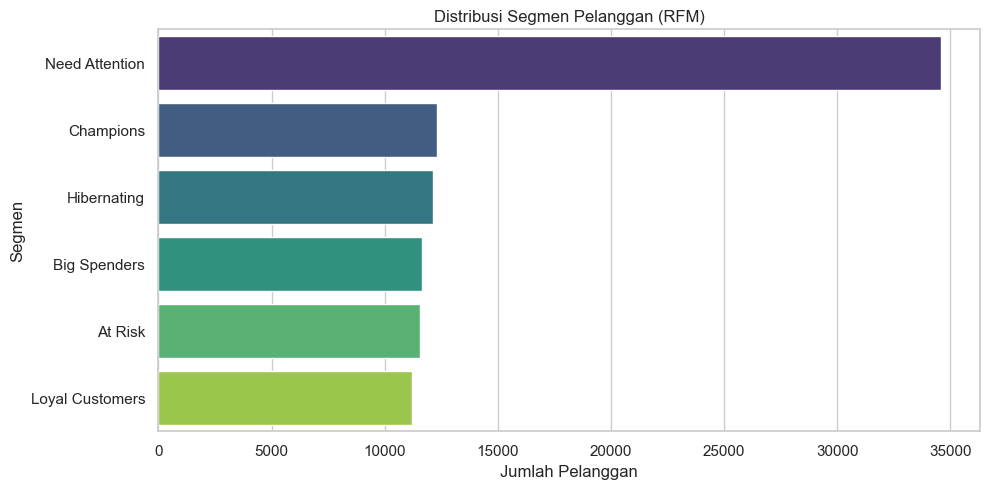

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_12980\2808596092.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=segment_value, x="Monetary", y="Segment", palette="magma")


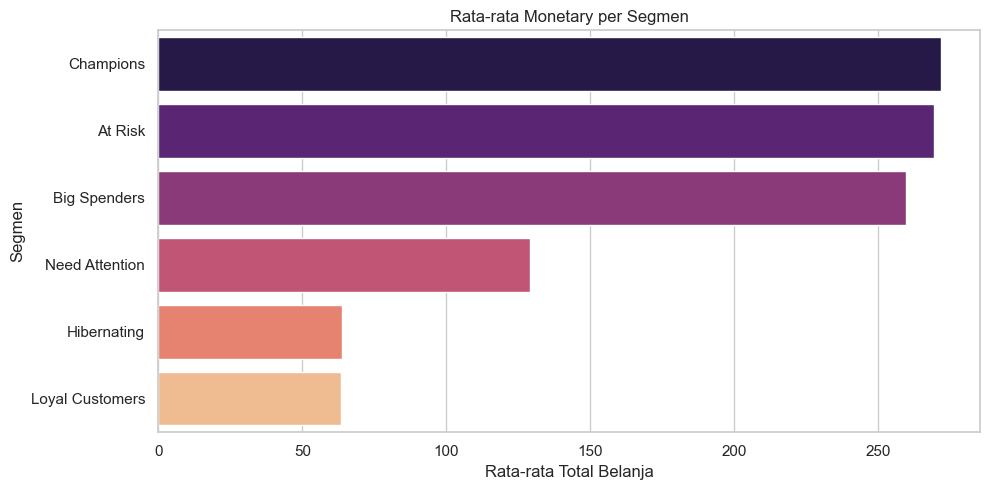

In [25]:
# =========================
# ANALISIS LANJUTAN: RFM
# =========================

# Pastikan customer_unique_id tersedia di delivered_orders
if "customer_unique_id" not in delivered_orders.columns:
    delivered_orders = delivered_orders.merge(
        customers_df[["customer_id", "customer_unique_id"]],
        on="customer_id",
        how="left"
    )

# Snapshot date untuk hitung recency
snapshot_date = delivered_orders["order_purchase_timestamp"].max() + pd.Timedelta(days=1)

# RFM table
rfm = delivered_orders.groupby("customer_unique_id").agg(
    Recency=("order_purchase_timestamp", lambda x: (snapshot_date - x.max()).days),
    Frequency=("order_id", "nunique"),
    Monetary=("revenue", "sum")
).reset_index()

# Skoring kuartil (1-4)
rfm["R_Score"] = pd.qcut(rfm["Recency"], 4, labels=[4, 3, 2, 1]).astype(int)
rfm["F_Score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 4, labels=[1, 2, 3, 4]).astype(int)
rfm["M_Score"] = pd.qcut(rfm["Monetary"].rank(method="first"), 4, labels=[1, 2, 3, 4]).astype(int)

rfm["RFM_Score"] = rfm["R_Score"].astype(str) + rfm["F_Score"].astype(str) + rfm["M_Score"].astype(str)

# Segmentasi sederhana tanpa ML
conditions = [
    (rfm["R_Score"] >= 3) & (rfm["F_Score"] >= 3) & (rfm["M_Score"] >= 3),
    (rfm["R_Score"] >= 3) & (rfm["F_Score"] >= 3),
    (rfm["R_Score"] >= 3) & (rfm["M_Score"] >= 3),
    (rfm["R_Score"] <= 2) & (rfm["F_Score"] >= 3) & (rfm["M_Score"] >= 3),
    (rfm["R_Score"] <= 2) & (rfm["F_Score"] <= 2) & (rfm["M_Score"] <= 2)
]
choices = ["Champions", "Loyal Customers", "Big Spenders", "At Risk", "Hibernating"]
rfm["Segment"] = np.select(conditions, choices, default="Need Attention")

print("Ringkasan RFM:")
print(rfm[["Recency", "Frequency", "Monetary"]].describe().round(2))

print("\nDistribusi Segmen:")
print(rfm["Segment"].value_counts())

# Visualisasi segmen
plt.figure(figsize=(10, 5))
sns.countplot(data=rfm, y="Segment", order=rfm["Segment"].value_counts().index, palette="viridis")
plt.title("Distribusi Segmen Pelanggan (RFM)")
plt.xlabel("Jumlah Pelanggan")
plt.ylabel("Segmen")
plt.tight_layout()
plt.show()

# Rata-rata Monetary per segmen
segment_value = rfm.groupby("Segment", as_index=False)["Monetary"].mean().sort_values("Monetary", ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=segment_value, x="Monetary", y="Segment", palette="magma")
plt.title("Rata-rata Monetary per Segmen")
plt.xlabel("Rata-rata Total Belanja")
plt.ylabel("Segmen")
plt.tight_layout()
plt.show()

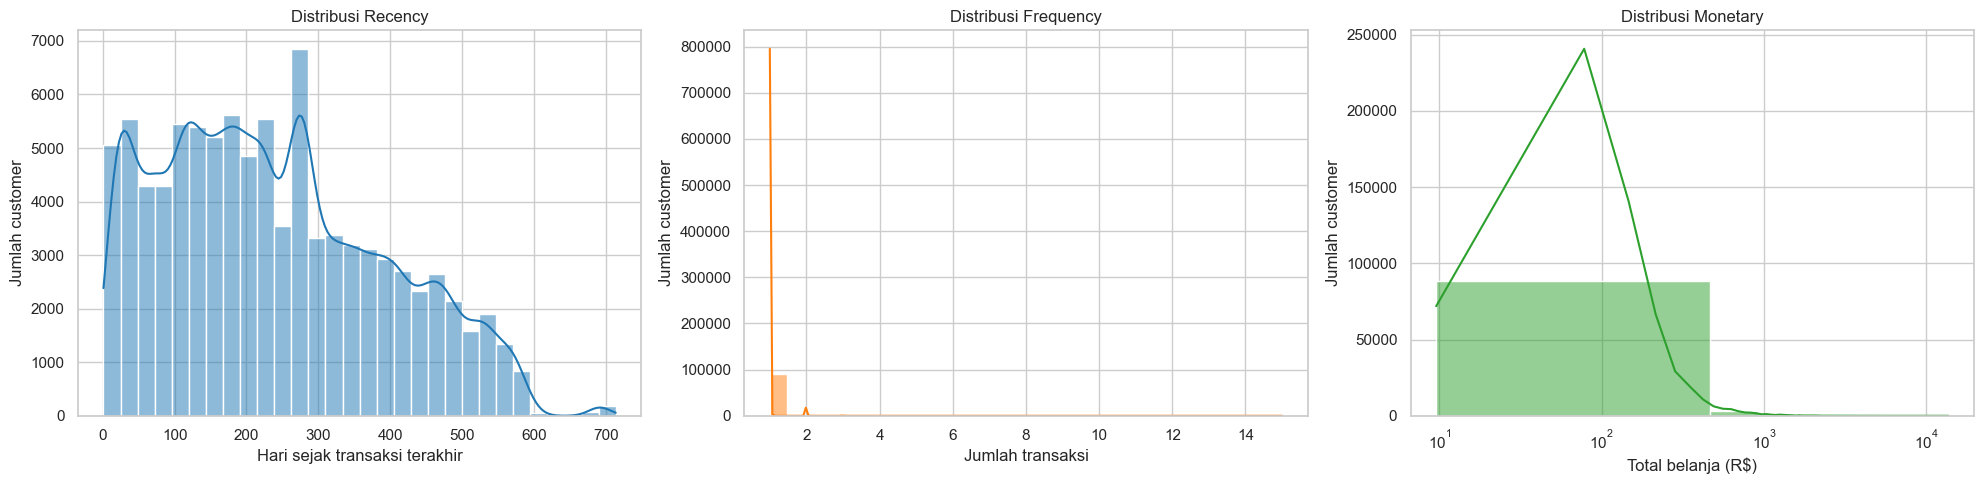

In [26]:
# =========================
# VISUALISASI SETIAP RFM
# =========================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1) Recency (semakin kecil semakin baik)
sns.histplot(rfm["Recency"], bins=30, kde=True, color="#1f77b4", ax=axes[0])
axes[0].set_title("Distribusi Recency")
axes[0].set_xlabel("Hari sejak transaksi terakhir")
axes[0].set_ylabel("Jumlah customer")

# 2) Frequency (jumlah transaksi)
sns.histplot(rfm["Frequency"], bins=30, kde=True, color="#ff7f0e", ax=axes[1])
axes[1].set_title("Distribusi Frequency")
axes[1].set_xlabel("Jumlah transaksi")
axes[1].set_ylabel("Jumlah customer")

# 3) Monetary (total belanja) -> biasanya skew, pakai log scale agar terbaca
sns.histplot(rfm["Monetary"], bins=30, kde=True, color="#2ca02c", ax=axes[2])
axes[2].set_title("Distribusi Monetary")
axes[2].set_xlabel("Total belanja (R$)")
axes[2].set_ylabel("Jumlah customer")
axes[2].set_xscale("log")

plt.tight_layout()
plt.show()

**insight**
- Segmentasi RFM menunjukkan segmen Need Attention paling dominan (sekitar sepertiga total pelanggan), artinya banyak pelanggan belum cukup baru/sering/tinggi nilainya dan perlu campaign re-engagement.
- Segmen bernilai tinggi (Champions, At Risk, dan Big Spenders) memiliki rata-rata monetary tertinggi; ini menandakan kontribusi revenue terbesar datang dari kelompok pelanggan tertentu, bukan merata ke semua pelanggan.
- Rata-rata monetary segmen At Risk hampir setara dengan Champions, sehingga kelompok ini kritikal untuk diprioritaskan dalam strategi retensi (berisiko churn tapi nilainya tinggi).
- Distribusi Recency cenderung menyebar dengan konsentrasi di rentang menengah, menandakan campuran antara pelanggan aktif dan pelanggan yang mulai tidak aktif.
- Distribusi Frequency sangat right-skewed dan didominasi transaksi 1x, menunjukkan mayoritas customer masih one-time buyer; peluang terbesar ada pada peningkatan repeat purchase.
- Distribusi Monetary juga right-skewed (long tail), artinya hanya sebagian kecil pelanggan dengan belanja sangat tinggi yang mendorong nilai revenue total.
- Dari sudut clustering manual + binning, kombinasi pelanggan high spend dengan low recency perlu diperlakukan sebagai prioritas utama (retention + win-back), sedangkan pelanggan low spend dan one-time cocok untuk automasi nurture/promo dasar.

2. GEOSPATIAL ANALYSIS

In [27]:
# =========================
# GEOSPATIAL ANALYSIS
# =========================

# 1) Load geolocation data
geo_df = pd.read_csv('data/E-Commerce Public Dataset/geolocation_dataset.csv')

# 2) Siapkan data transaksi delivered + revenue per order
orders_delivered = orders_df[orders_df['order_status'] == 'delivered'][['order_id', 'customer_id']].copy()

order_revenue = order_items_df.groupby('order_id', as_index=False).agg(
    total_revenue=('price', 'sum'),
    total_freight=('freight_value', 'sum')
)
order_revenue['gross_revenue'] = order_revenue['total_revenue'] + order_revenue['total_freight']

# 3) Gabungkan dengan customer (state, city, zip)
cust_loc = customers_df[['customer_id', 'customer_state', 'customer_city', 'customer_zip_code_prefix']].copy()

geo_sales = (
    orders_delivered
    .merge(order_revenue[['order_id', 'gross_revenue']], on='order_id', how='left')
    .merge(cust_loc, on='customer_id', how='left')
)

# 4) Ambil centroid per state dari geolocation dataset
state_centroid = geo_df.groupby('geolocation_state', as_index=False).agg(
    lat=('geolocation_lat', 'mean'),
    lng=('geolocation_lng', 'mean')
)

# 5) Ringkasan performa per state
state_perf = geo_sales.groupby('customer_state', as_index=False).agg(
    total_orders=('order_id', 'nunique'),
    total_customers=('customer_id', 'nunique'),
    total_revenue=('gross_revenue', 'sum')
)

state_map_df = state_perf.merge(
    state_centroid,
    left_on='customer_state',
    right_on='geolocation_state',
    how='left'
)

# =========================
# PETA 1: BUBBLE MAP PER STATE
# =========================
map_state = folium.Map(location=[-14.2350, -51.9253], zoom_start=4, tiles='cartodbpositron')

max_rev = state_map_df['total_revenue'].max()

for _, row in state_map_df.dropna(subset=['lat', 'lng']).iterrows():
    radius = 5 + (row['total_revenue'] / max_rev) * 25
    tooltip_text = (
        f"State: {row['customer_state']}<br>"
        f"Total Revenue: R$ {row['total_revenue']:,.0f}<br>"
        f"Total Orders: {row['total_orders']:,}<br>"
        f"Total Customers: {row['total_customers']:,}"
    )

    folium.CircleMarker(
        location=[row['lat'], row['lng']],
        radius=radius,
        color='#1f77b4',
        fill=True,
        fill_opacity=0.65,
        tooltip=tooltip_text
    ).add_to(map_state)

map_state

In [28]:
# =========================
# PETA 2: HEATMAP BERDASARKAN ZIP CODE
# =========================

# Titik lat/lng rata-rata per zip prefix
zip_centroid = geo_df.groupby('geolocation_zip_code_prefix', as_index=False).agg(
    lat=('geolocation_lat', 'mean'),
    lng=('geolocation_lng', 'mean')
)

# Kinerja per zip prefix customer
zip_perf = geo_sales.groupby('customer_zip_code_prefix', as_index=False).agg(
    total_revenue=('gross_revenue', 'sum'),
    total_orders=('order_id', 'nunique')
)

zip_map_df = zip_perf.merge(
    zip_centroid,
    left_on='customer_zip_code_prefix',
    right_on='geolocation_zip_code_prefix',
    how='left'
).dropna(subset=['lat', 'lng', 'total_revenue'])

# Data heatmap: lat, lng, weight(revenue)
heat_data = zip_map_df[['lat', 'lng', 'total_revenue']].values.tolist()

map_heat = folium.Map(location=[-14.2350, -51.9253], zoom_start=4, tiles='cartodbpositron')

HeatMap(
    heat_data,
    radius=12,
    blur=18,
    min_opacity=0.25,
    max_zoom=7
).add_to(map_heat)

map_heat

3. Clustering

Distribusi Manual Cluster:
manual_cluster
One-time Buyer | Low Value       72176
One-time Buyer | Mid Value       16687
One-time Buyer | High Value       1694
Occasional Buyer | Mid Value      1442
Occasional Buyer | Low Value      1193
Occasional Buyer | High Value      119
Regular Buyer | Mid Value           27
Regular Buyer | High Value          12
Power Buyer | High Value             4
Regular Buyer | Low Value            3
Power Buyer | Mid Value              1
Name: count, dtype: int64


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_12980\3559704483.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


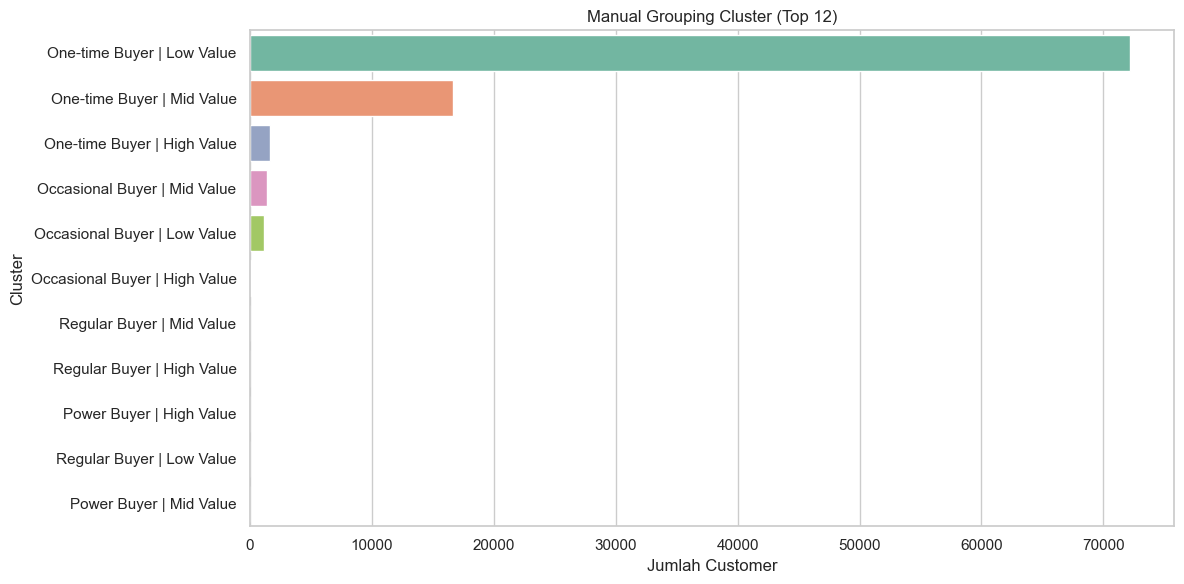


Distribusi Frequency Bin:
frequency_bin
1x      90557
2-3x     2754
4-6x       42
>6x         5
Name: count, dtype: int64

Distribusi Monetary Bin:
monetary_bin
Q1-Low        23345
Q2-MidLow     23342
Q3-MidHigh    23332
Q4-High       23339
Name: count, dtype: int64


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_12980\3559704483.py:110: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=cust_cluster, x="recency_bin", ax=axes[0], palette="Blues")
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_12980\3559704483.py:116: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=cust_cluster, x="frequency_bin", ax=axes[1], palette="Oranges")
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_12980\3559704483.py:121: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=cust_cluster, x="monetary_bin", ax=axes[2], palette="G

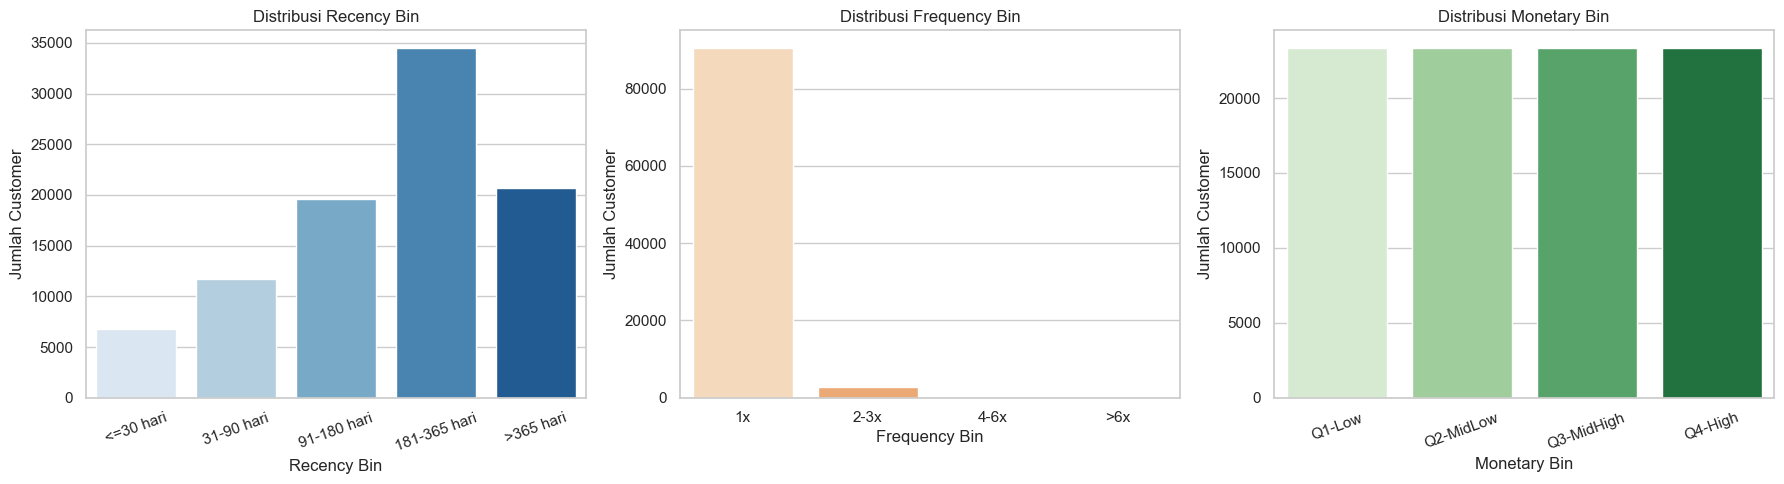


Preview hasil clustering:


,customer_unique_id,recency_days,total_orders,total_spend,manual_cluster,recency_bin,frequency_bin,monetary_bin
3724,0a0a92112bd4c708ca5fde585afaa872,334,1,13664.08,One-time Buyer | High Value,181-365 hari,1x,Q4-High
79636,da122df9eeddfedc1dc1f5349a1a690c,515,2,7571.63,Occasional Buyer | High Value,>365 hari,2-3x,Q4-High
43168,763c8b1c9c68a0229c42c9fc6f662b93,46,1,7274.88,One-time Buyer | High Value,31-90 hari,1x,Q4-High
80463,dc4802a71eae9be1dd28f5d788ceb526,563,1,6929.31,One-time Buyer | High Value,>365 hari,1x,Q4-High
25436,459bef486812aa25204be022145caa62,35,1,6922.21,One-time Buyer | High Value,31-90 hari,1x,Q4-High
93081,ff4159b92c40ebe40454e3e6a7c35ed6,462,1,6726.66,One-time Buyer | High Value,>365 hari,1x,Q4-High
23411,4007669dec559734d6f53e029e360987,279,1,6081.54,One-time Buyer | High Value,181-365 hari,1x,Q4-High
87148,eebb5dda148d3893cdaf5b5ca3040ccb,498,1,4764.34,One-time Buyer | High Value,>365 hari,1x,Q4-High
26640,48e1ac109decbb87765a3eade6854098,69,1,4681.78,One-time Buyer | High Value,31-90 hari,1x,Q4-High
73127,c8460e4251689ba205045f3ea17884a1,22,4,4655.88,Regular Buyer | High Value,<=30 hari,4-6x,Q4-High


In [29]:
# ==========================================
# CLUSTERING NON-ML: MANUAL GROUPING + BINNING
# ==========================================

# Pastikan customer_unique_id ada
if "customer_unique_id" not in delivered_orders.columns:
    delivered_orders = delivered_orders.merge(
        customers_df[["customer_id", "customer_unique_id"]],
        on="customer_id",
        how="left"
    )

# Snapshot date untuk recency
snapshot_date = delivered_orders["order_purchase_timestamp"].max() + pd.Timedelta(days=1)

# Ringkasan customer-level
cust_cluster = delivered_orders.groupby("customer_unique_id", as_index=False).agg(
    last_purchase=("order_purchase_timestamp", "max"),
    total_orders=("order_id", "nunique"),
    total_spend=("revenue", "sum")
)

cust_cluster["recency_days"] = (snapshot_date - cust_cluster["last_purchase"]).dt.days
cust_cluster["avg_order_value"] = cust_cluster["total_spend"] / cust_cluster["total_orders"]

# ------------------------------------------
# 1) MANUAL GROUPING (berdasarkan aturan bisnis)
# ------------------------------------------

# Group berdasarkan jumlah transaksi
conditions_freq = [
    cust_cluster["total_orders"] == 1,
    cust_cluster["total_orders"].between(2, 3),
    cust_cluster["total_orders"].between(4, 6),
    cust_cluster["total_orders"] >= 7
]
choices_freq = ["One-time Buyer", "Occasional Buyer", "Regular Buyer", "Power Buyer"]
cust_cluster["manual_freq_group"] = np.select(conditions_freq, choices_freq, default="Unclassified")

# Group berdasarkan total belanja (threshold bisnis sederhana)
conditions_spend = [
    cust_cluster["total_spend"] < 200,
    cust_cluster["total_spend"].between(200, 800, inclusive="left"),
    cust_cluster["total_spend"] >= 800
]
choices_spend = ["Low Value", "Mid Value", "High Value"]
cust_cluster["manual_spend_group"] = np.select(conditions_spend, choices_spend, default="Unclassified")

# Gabungan cluster manual
cust_cluster["manual_cluster"] = cust_cluster["manual_freq_group"] + " | " + cust_cluster["manual_spend_group"]

print("Distribusi Manual Cluster:")
print(cust_cluster["manual_cluster"].value_counts().head(15))

# Visualisasi manual grouping
plt.figure(figsize=(12, 6))
sns.countplot(
    data=cust_cluster,
    y="manual_cluster",
    order=cust_cluster["manual_cluster"].value_counts().index[:12],
    palette="Set2"
)
plt.title("Manual Grouping Cluster (Top 12)")
plt.xlabel("Jumlah Customer")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

# ------------------------------------------
# 2) BINNING (interval/kategori)
# ------------------------------------------

# Binning recency (days since last purchase)
cust_cluster["recency_bin"] = pd.cut(
    cust_cluster["recency_days"],
    bins=[-1, 30, 90, 180, 365, np.inf],
    labels=["<=30 hari", "31-90 hari", "91-180 hari", "181-365 hari", ">365 hari"]
)

# Binning frequency (jumlah order)
cust_cluster["frequency_bin"] = pd.cut(
    cust_cluster["total_orders"],
    bins=[0, 1, 3, 6, np.inf],
    labels=["1x", "2-3x", "4-6x", ">6x"]
)

# Binning monetary (berbasis kuartil agar seimbang)
cust_cluster["monetary_bin"] = pd.qcut(
    cust_cluster["total_spend"],
    q=4,
    labels=["Q1-Low", "Q2-MidLow", "Q3-MidHigh", "Q4-High"]
)

# Cluster code dari binning
cust_cluster["binning_cluster"] = (
    cust_cluster["recency_bin"].astype(str) + " | " +
    cust_cluster["frequency_bin"].astype(str) + " | " +
    cust_cluster["monetary_bin"].astype(str)
)

print("\nDistribusi Frequency Bin:")
print(cust_cluster["frequency_bin"].value_counts().sort_index())

print("\nDistribusi Monetary Bin:")
print(cust_cluster["monetary_bin"].value_counts().sort_index())

# Visualisasi binning
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=cust_cluster, x="recency_bin", ax=axes[0], palette="Blues")
axes[0].set_title("Distribusi Recency Bin")
axes[0].set_xlabel("Recency Bin")
axes[0].set_ylabel("Jumlah Customer")
axes[0].tick_params(axis="x", rotation=20)

sns.countplot(data=cust_cluster, x="frequency_bin", ax=axes[1], palette="Oranges")
axes[1].set_title("Distribusi Frequency Bin")
axes[1].set_xlabel("Frequency Bin")
axes[1].set_ylabel("Jumlah Customer")

sns.countplot(data=cust_cluster, x="monetary_bin", ax=axes[2], palette="Greens")
axes[2].set_title("Distribusi Monetary Bin")
axes[2].set_xlabel("Monetary Bin")
axes[2].set_ylabel("Jumlah Customer")
axes[2].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

# Tabel contoh hasil clustering
cluster_preview = cust_cluster[[
    "customer_unique_id", "recency_days", "total_orders", "total_spend",
    "manual_cluster", "recency_bin", "frequency_bin", "monetary_bin"
]].sort_values(["total_spend", "total_orders"], ascending=False)

print("\nPreview hasil clustering:")
display(cluster_preview.head(20))

**insight CLustering Manual + Binning**
- Struktur pelanggan sangat didominasi pembeli sekali transaksi.
One-time Buyer totalnya 90,557 dari 93,358 pelanggan, sekitar 97.0%.
Ini konsisten dengan Frequency Bin 1x yang juga 90,557.
- Segmen terbesar adalah One-time Buyer | Low Value dengan 72,176 pelanggan, sekitar 77.3% dari total.
Artinya mayoritas pelanggan masih berkontribusi kecil dan belum repeat.
- Segmen One-time Buyer | Mid Value masih cukup besar, 16,687 pelanggan atau sekitar 17.9%. Ini adalah kandidat terbaik untuk program konversi dari first purchase ke second purchase.
- Pelanggan berulang masih sangat kecil.
2-3x hanya 2,754 pelanggan sekitar 2.95%, 4-6x hanya 42, dan lebih dari 6x hanya 5. Jadi bottleneck utama bisnis adalah retensi, bukan akuisisi awal.
- Segmen bernilai tinggi tapi loyal (Regular/Power, High Value) sangat sedikit. Ini menunjukkan customer base bernilai tinggi jangka panjang belum terbentuk kuat.
- Dari recency bin, porsi terbesar terlihat pada rentang 181-365 hari. Ini menandakan banyak pelanggan sudah lama tidak belanja dan masuk kategori win-back target.
- Monetary bin terlihat seimbang karena dibuat dengan qcut kuartil. Jadi grafik ini berguna untuk pembagian kelompok, tetapi bukan bukti distribusi alami belanja.
- Implikasi bisnis:
   - prioritas 1 adalah reactivation campaign untuk pelanggan 91-365 hari,
   - prioritas 2 adalah mendorong pembeli 1x menjadi 2x lewat voucher repeat order dan bundling,
   - prioritas 3 adalah perlakuan VIP untuk kelompok High Value agar tidak churn.

## Conclusion

## Conclusion

- **Conclusion Pertanyaan 1**  
Pada tahun 2018, kategori **health_beauty** terbukti menjadi penggerak utama revenue dengan total **R$ 866,810.34** atau **10.26%** dari total revenue tahunan. Performanya menunjukkan tren yang menguat dari Januari hingga Agustus, dengan pertumbuhan **+65.44%** (dari **R$ 81,989.68** ke **R$ 135,644.51**), serta peningkatan kontribusi bulanan dari **7.61%** menjadi **13.76%**. Temuan ini menegaskan bahwa **health_beauty** layak dijadikan prioritas strategi pertumbuhan, sambil tetap memantau fluktuasi bulanan agar momentum tetap terjaga.

- **Conclusion Pertanyaan 2**  
Pada periode 2016-2018 (dengan syarat minimum 30 unique customers), terdapat **389 kota** yang valid untuk analisis, dan **saquarema** menjadi kota dengan repeat customer rate tertinggi (**13.16%**), diikuti **extrema (10.53%)** dan **luziania (10.00%)**. Namun, nilai **avg_orders_per_customer** di top-15 kota yang hanya berada pada rentang **1.07-1.20** menunjukkan bahwa perilaku repeat purchase masih relatif rendah secara absolut. Selain itu, tren tahunan pada top 3 kota cenderung menurun atau stagnan. Secara keseluruhan, perusahaan perlu memfokuskan strategi pada **retensi pelanggan**, terutama untuk mendorong pelanggan first purchase menjadi second purchase di kota dengan basis pelanggan yang sudah cukup besar.

In [30]:
# Membuat main_data.py
# Pastikan customer_unique_id ada
if "customer_unique_id" not in delivered_orders.columns:
    delivered_orders = delivered_orders.merge(
        customers_df[["customer_id", "customer_unique_id"]],
        on="customer_id",
        how="left"
    )

# Pilih kolom inti untuk dashboard
main_data = delivered_orders[
    [
        "order_id",
        "customer_id",
        "customer_unique_id",
        "order_purchase_timestamp",
        "year",
        "month",
        "customer_city",
        "customer_state",
        "product_category_name_english",
        "revenue",
        "price",
        "freight_value"
    ]
].copy()

# Rapikan missing category
main_data["product_category_name_english"] = (
    main_data["product_category_name_english"]
    .fillna("uncategorized")
)

# Simpan ke folder dashboard
os.makedirs("dashboard", exist_ok=True)
main_data.to_csv("dashboard/main_data.csv", index=False)

print("Berhasil membuat: dashboard/main_data.csv")
print("Shape:", main_data.shape)
main_data.head()

Berhasil membuat: dashboard/main_data.csv
Shape: (110197, 12)


,order_id,customer_id,customer_unique_id,order_purchase_timestamp,year,month,customer_city,customer_state,product_category_name_english,revenue,price,freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff,2017-10-02 10:56:33,2017,10,sao paulo,SP,housewares,38.71,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,af07308b275d755c9edb36a90c618231,2018-07-24 20:41:37,2018,7,barreiras,BA,perfumery,141.46,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,3a653a41f6f9fc3d2a113cf8398680e8,2018-08-08 08:38:49,2018,8,vianopolis,GO,auto,179.12,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,7c142cf63193a1473d2e66489a9ae977,2017-11-18 19:28:06,2017,11,sao goncalo do amarante,RN,pet_shop,72.20,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,72632f0f9dd73dfee390c9b22eb56dd6,2018-02-13 21:18:39,2018,2,santo andre,SP,stationery,28.62,19.90,8.72
